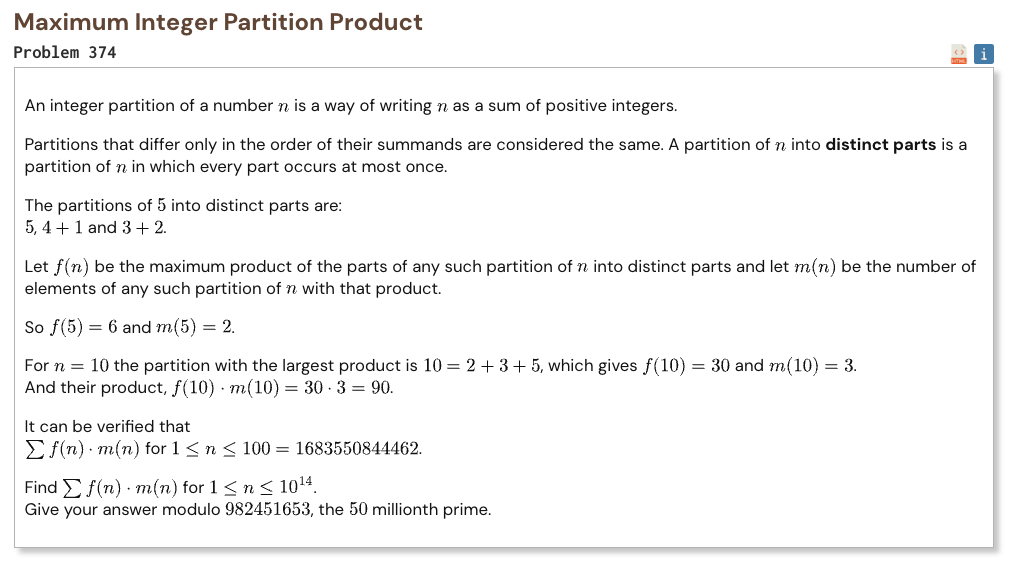

## Initial approach

* for a fixed number of parts, the best partition keeps the parts as close as possible
* the optimal partitions appear in blocks based on consecutive integers
* inside one block, each new value increases the largest suitable parts by one
* the products in a block simplify to factorial values multiplied by modular fractions
* keep a running factorial and a running modular harmonic sum
* use array to store modular inverses with much lower memory usage than a normal Python list
* handle the final incomplete block separately and return the result modulo the given prime

In [1]:
import math
from array import array

MOD = 982451653

def solve(limit):
    max_k = (math.isqrt(8 * limit + 9) - 3) // 2

    while (max_k + 1) * (max_k + 4) // 2 <= limit:
        max_k += 1

    while max_k * (max_k + 3) // 2 > limit:
        max_k -= 1

    inverses = array("I", [0]) * (max_k + 3)
    inverses[1] = 1

    for i in range(2, max_k + 3):
        inverses[i] = (
            MOD - (MOD // i) * inverses[MOD % i] % MOD
        ) % MOD

    total = 1
    factorial = 1
    harmonic = 0

    for k in range(1, max_k + 1):
        factorial = factorial * (k + 1) % MOD

        if k == 1:
            harmonic = (inverses[2] + inverses[3]) % MOD
        else:
            harmonic = (harmonic + inverses[k + 2]) % MOD

        block_start = k * (k + 3) // 2
        block_end = block_start + k + 1

        if block_end <= limit:
            product_sum = (
                (k + 2) * harmonic
                + (k + 3) * inverses[2]
            ) % MOD

            total = (
                total
                + k * factorial % MOD * product_sum
            ) % MOD
        else:
            count = limit - block_start + 1
            first_denominator = k + 3 - count
            partial_harmonic = 0

            for denominator in range(first_denominator, k + 3):
                partial_harmonic += inverses[denominator]

            partial_harmonic %= MOD
            product_sum = (k + 2) * partial_harmonic % MOD

            total = (
                total
                + k * factorial % MOD * product_sum
            ) % MOD

            break

    return total

assert solve(10) == 254
assert solve(100) == 1683550844462 % MOD

In [2]:
%%time
result = solve(10 ** 14)
print("Result:", result)

Result: 334420941
CPU times: user 7.23 s, sys: 55.7 ms, total: 7.28 s
Wall time: 7.34 s
